In [40]:
import pandas as pd
df = pd.read_csv(r"C:\Users\abhin\Downloads\archive\Sample - Superstore.csv", encoding="latin1")
# df.head()
# df.shape
# df.info()
# df.duplicated().sum()
# df["Order Date"] = pd.to_datetime(df["Order Date"])
# df["Ship Date"] = pd.to_datetime(df["Ship Date"])
# df.dtypes
# df.isnull().sum()
# Profit margin %

# df.head()


In [41]:
import pandas as pd

df = pd.read_csv(r"C:\Users\abhin\Downloads\archive\Sample - Superstore.csv", encoding='latin1')

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

print(df["Order Date"].dtype)
print(df["Ship Date"].dtype)
df.dtypes
df["Profit Margin"] = (df["Profit"] / df["Sales"]) * 100
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days
df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month

df.head()

datetime64[us]
datetime64[us]


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Profit Margin,Shipping Days,Order Year,Order Month
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,16.00,3,2016,11
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,30.00,3,2016,11
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,47.00,4,2016,6
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,-40.00,7,2015,10
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,11.25,7,2015,10


In [42]:
correlation = df["Discount"].corr(df["Profit"])
print(correlation)

-0.21948745637176834


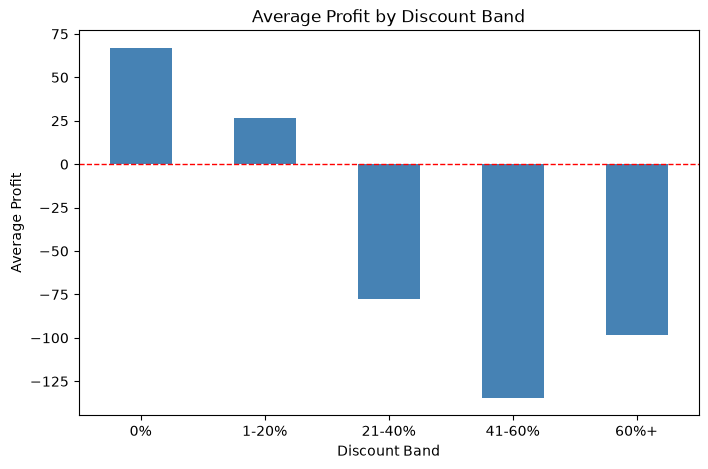

In [47]:
import matplotlib.pyplot as plt

# Create discount bands
bins = [-0.01, 0, 0.2, 0.4, 0.6, 1]
labels = ['0%', '1-20%', '21-40%', '41-60%', '60%+']
df['Discount Band'] = pd.cut(df['Discount'], bins=bins, labels=labels)

# Average profit per band
avg_profit = df.groupby('Discount Band')['Profit'].mean()

# Bar chart
plt.figure(figsize=(8,5))
avg_profit.plot(kind='bar', color='steelblue')
plt.xlabel("Discount Band")
plt.ylabel("Average Profit")
plt.title("Average Profit by Discount Band")
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xticks(rotation=0)
plt.show()

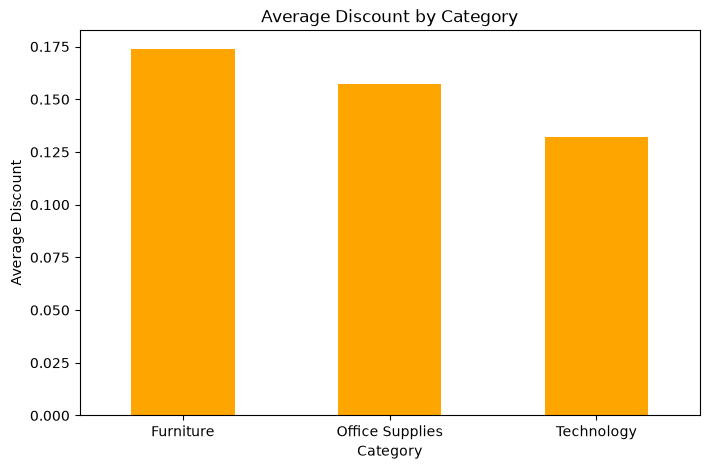

In [48]:
avg_discount_by_cat = df.groupby('Category')['Discount'].mean()

plt.figure(figsize=(8,5))
avg_discount_by_cat.plot(kind='bar', color='orange')
plt.xlabel("Category")
plt.ylabel("Average Discount")
plt.title("Average Discount by Category")
plt.xticks(rotation=0)
plt.show()

In [49]:
df.to_csv('superstore_cleaned.csv', index=False)
print("Saved successfully")

Saved successfully
